# 04 — Train Final Deep Learning Models (Keras v3 / PyTorch backend)

Loads best hyperparameters from notebook 03, trains FNN and LSTM to full
convergence, saves models to files.

> **Runtime: FNN ~5 min · LSTM ~20 min**


In [1]:
# ── MUST be first cell ───────────────────────────────────────────────────
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import matplotlib.pyplot as plt
import json, time
import keras
from keras import layers

print(f"Keras  : {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")
assert keras.backend.backend() == "torch", "Restart kernel — backend must be torch"


Keras  : 3.14.1
Backend: torch


In [2]:
# ── Load data and hyperparameters ─────────────────────────────────────────
X_train = np.load("data/X_train_dense.npy")
X_val   = np.load("data/X_val_dense.npy")
seq_tr  = np.load("data/seq_train.npy")
seq_va  = np.load("data/seq_val.npy")
num_tr  = np.load("data/X_train_num.npy")
num_va  = np.load("data/X_val_num.npy")
y_train = np.load("data/y_train.npy")
y_val   = np.load("data/y_val.npy")

with open("data/meta.json")          as f: meta     = json.load(f)
with open("data/best_hparams_fnn.json")  as f: hp_fnn  = json.load(f)
with open("data/best_hparams_lstm.json") as f: hp_lstm = json.load(f)

INPUT_DIM = meta["INPUT_DIM"]
MAX_WORDS = meta["MAX_WORDS"]
MAX_LEN   = meta["MAX_LEN"]

print(f"FNN  best hparams: {hp_fnn}")
print(f"LSTM best hparams: {hp_lstm}")
print(f"Train: {len(y_train):,} | Val: {len(y_val):,}")


FNN  best hparams: {'n_layers': 4, 'units': 256, 'dropout': 0.30000000000000004, 'lr': 0.00033764319636739114, 'batch_norm': False}
LSTM best hparams: {'embed_dim': 256, 'lstm_units': 128, 'dropout': 0.2, 'lr': 0.003148367158154625}
Train: 34,999 | Val: 7,501


In [3]:
# ════════════════════════════════════════════════════════════════════════
# MODEL A — FNN (Week 2)
# ════════════════════════════════════════════════════════════════════════
def build_fnn_final(hp):
    """FNN on TF-IDF + numeric input (Week 2 architecture)."""
    inp = keras.Input(shape=(INPUT_DIM,), name="bow_input")
    x = inp
    for _ in range(hp["n_layers"]):
        x = layers.Dense(hp["units"], activation="relu")(x)
        if hp.get("batch_norm", False):
            x = layers.BatchNormalization()(x)
        x = layers.Dropout(hp["dropout"])(x)
    out = layers.Dense(1, activation="linear", name="score")(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp["lr"]),
        loss="mse", metrics=["mae"],
    )
    return model

fnn_model = build_fnn_final(hp_fnn)
fnn_model.summary()

cbs_fnn = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1),
]

print("\nTraining FNN:")
t0 = time.time()
hist_fnn = fnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=256,
    callbacks=cbs_fnn, verbose=1,
)
print(f"\n✅ FNN done in {(time.time()-t0)/60:.1f} min")
print(f"Best val MAE : {min(hist_fnn.history['val_mae']):.4f}")
print(f"Best val RMSE: {min(np.sqrt(hist_fnn.history['val_loss'])):.4f}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bow_input (InputLayer)          │ (None, 5005)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,281,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ score (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,479,169 (5.64 MB)

 Trainable params: 1,479,169 (5.64 MB)

 Non-trainable params: 0 (0.00 B)


Training FNN:
Epoch 1/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 13.9427 - mae: 2.6259 - val_loss: 1.7881 - val_mae: 1.0461 - learning_rate: 3.3764e-04
Epoch 2/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4181 - mae: 1.2299 - val_loss: 1.3722 - val_mae: 0.9024 - learning_rate: 3.3764e-04
Epoch 3/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0094 - mae: 1.1195 - val_loss: 1.3618 - val_mae: 0.9120 - learning_rate: 3.3764e-04
Epoch 4/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7678 - mae: 1.0510 - val_loss: 1.2964 - val_mae: 0.8825 - learning_rate: 3.3764e-04
Epoch 5/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6178 - mae: 1.0018 - val_loss: 1.2671 - val_mae: 0.8608 - learning_rate: 3.3764e-04
Epoch 6/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4855 - mae: 0.9596 - val_loss: 1.3632 - val_mae: 0.9125 - learning_rate: 3.3764e-04
Epoch 7/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.3580 - mae: 0.9175 - val_loss: 1.3145 -

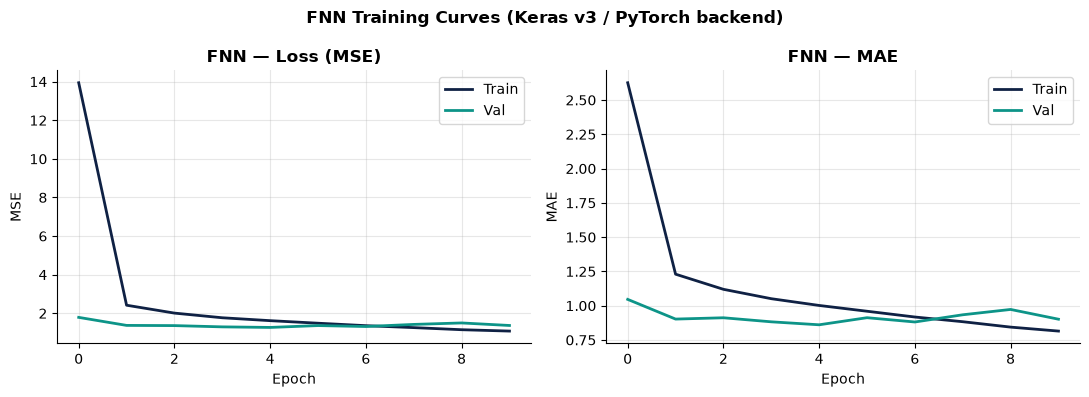

In [4]:
# ── FNN training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_fnn.history["loss"],     label="Train", color="#0F2144", lw=2)
axes[0].plot(hist_fnn.history["val_loss"], label="Val",   color="#0D9488", lw=2)
axes[0].set_title("FNN — Loss (MSE)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(hist_fnn.history["mae"],     label="Train", color="#0F2144", lw=2)
axes[1].plot(hist_fnn.history["val_mae"], label="Val",   color="#0D9488", lw=2)
axes[1].set_title("FNN — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("FNN Training Curves (Keras v3 / PyTorch backend)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_fnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
fnn_model.save("data/fnn_model.keras")
print("✅ FNN saved → data/fnn_model.keras")


✅ FNN saved → data/fnn_model.keras


In [6]:
# ════════════════════════════════════════════════════════════════════════
# MODEL B — LSTM (Week 4)
# ════════════════════════════════════════════════════════════════════════
def build_lstm_final(hp):
    """
    LSTM with learned embeddings (Week 4 architecture).
    Text branch: Embedding(vocab, embed_dim, mask_zero=True) → LSTM → Dropout
    Numeric branch: direct 5-feature input
    Head: Concatenate → Dense(64, ReLU) → Dense(1, linear)
    """
    text_input = keras.Input(shape=(MAX_LEN,), dtype="int32", name="text_input")
    x = layers.Embedding(input_dim=MAX_WORDS, output_dim=hp["embed_dim"],
                         mask_zero=True, name="embedding")(text_input)
    x = layers.LSTM(hp["lstm_units"], name="lstm")(x)
    x = layers.Dropout(hp["dropout"])(x)

    num_input = keras.Input(shape=(5,), name="numeric_input")
    combined  = layers.Concatenate()([x, num_input])
    combined  = layers.Dense(64, activation="relu")(combined)
    out       = layers.Dense(1, activation="linear", name="score")(combined)

    model = keras.Model([text_input, num_input], out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp["lr"], clipnorm=1.0),
        loss="mse", metrics=["mae"],
    )
    return model

lstm_model = build_lstm_final(hp_lstm)
lstm_model.summary()

cbs_lstm = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=4, min_lr=1e-6, verbose=1),
]

print(f"\nTraining LSTM:")
print(f"  embed_dim={hp_lstm['embed_dim']}, lstm_units={hp_lstm['lstm_units']}, "
      f"lr={hp_lstm['lr']:.2e}")
t0 = time.time()
hist_lstm = lstm_model.fit(
    [seq_tr, num_tr], y_train,
    validation_data=([seq_va, num_va], y_val),
    epochs=50, batch_size=256,
    callbacks=cbs_lstm, verbose=1,
)
print(f"\n✅ LSTM done in {(time.time()-t0)/60:.1f} min")
print(f"Best val MAE : {min(hist_lstm.history['val_mae']):.4f}")
print(f"Best val RMSE: {min(np.sqrt(hist_lstm.history['val_loss'])):.4f}")

emb_std = lstm_model.get_layer("embedding").get_weights()[0].std()
print(f"Embedding weight std: {emb_std:.4f}  (>0.1 = properly trained)")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 256)  │  3,840,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 150)       │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    197,120 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 133)       │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,576 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,045,761 (15.43 MB)

 Trainable params: 4,045,761 (15.43 MB)

 Non-trainable params: 0 (0.00 B)


Training LSTM:
  embed_dim=256, lstm_units=128, lr=3.15e-03
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 36s 254ms/step - loss: 4.4614 - mae: 1.3691 - val_loss: 1.5343 - val_mae: 0.9081 - learning_rate: 0.0031
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 33s 244ms/step - loss: 1.4480 - mae: 0.9099 - val_loss: 1.3274 - val_mae: 0.8556 - learning_rate: 0.0031
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 33s 244ms/step - loss: 1.1412 - mae: 0.8072 - val_loss: 1.3014 - val_mae: 0.8586 - learning_rate: 0.0031
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 34s 250ms/step - loss: 0.9853 - mae: 0.7454 - val_loss: 1.3652 - val_mae: 0.8650 - learning_rate: 0.0031
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 34s 247ms/step - loss: 0.8663 - mae: 0.6960 - val_loss: 1.4010 - val_mae: 0.8904 - learning_rate: 0.0031
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - loss: 0.7777 - mae: 0.6608 - val_loss: 1.4276 - val_mae: 0.8893 - learning_rate: 0.0031
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.6973 

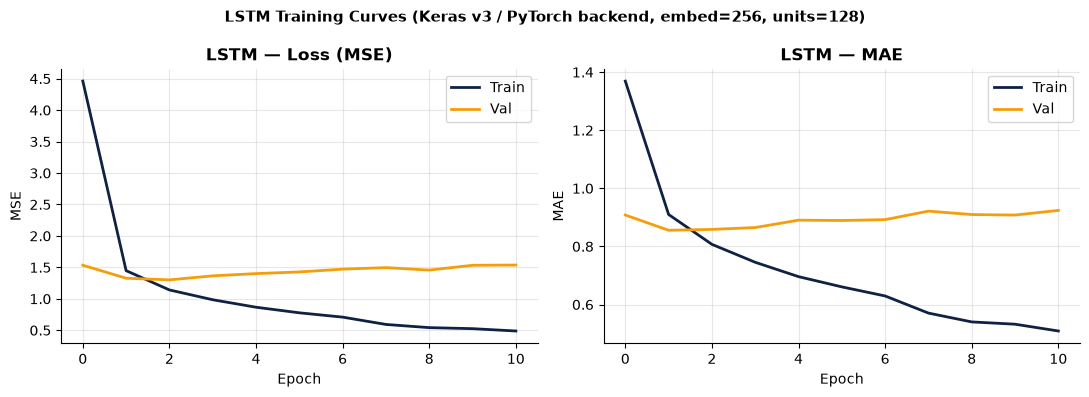

In [7]:
# ── LSTM training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_lstm.history["loss"],     label="Train", color="#0F2144", lw=2)
axes[0].plot(hist_lstm.history["val_loss"], label="Val",   color="#F59E0B", lw=2)
axes[0].set_title("LSTM — Loss (MSE)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(hist_lstm.history["mae"],     label="Train", color="#0F2144", lw=2)
axes[1].plot(hist_lstm.history["val_mae"], label="Val",   color="#F59E0B", lw=2)
axes[1].set_title("LSTM — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(f"LSTM Training Curves (Keras v3 / PyTorch backend, "
             f"embed={hp_lstm['embed_dim']}, units={hp_lstm['lstm_units']})",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_lstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
lstm_model.save("data/lstm_model.keras")
print("✅ LSTM saved → data/lstm_model.keras")


✅ LSTM saved → data/lstm_model.keras
